In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Dataset Loading:

In [2]:
df= pd.read_csv('../Data/data.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Data Understanding:

In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Data Preprocessing:

1. `TotalCharges` has `string` data-type. We need to convert it to `int` data-type.

In [9]:
df['TotalCharges']= pd.to_numeric(df['TotalCharges'], errors= 'coerce')

2. `customerID` column has no real meaning for the analysis. So we delete it.

In [10]:
df.drop(columns=['customerID'], inplace=True)

In [11]:
df1= df.copy(deep= True)

In [12]:
text_cols= []
for col in list(df.columns):
    if col not in list(df.describe()):
        text_cols.append(col)

print(text_cols)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [13]:
label= LabelEncoder()

print("Label Encoder Transformation:")

for col in text_cols:
    df1[col]= label.fit_transform(df1[col])
    print(f'{col} : ', df1[col].unique(), '=', label.inverse_transform(df1[col].unique()))

Label Encoder Transformation:
gender :  [0 1] = ['Female' 'Male']
Partner :  [1 0] = ['Yes' 'No']
Dependents :  [0 1] = ['No' 'Yes']
PhoneService :  [0 1] = ['No' 'Yes']
MultipleLines :  [1 0 2] = ['No phone service' 'No' 'Yes']
InternetService :  [0 1 2] = ['DSL' 'Fiber optic' 'No']
OnlineSecurity :  [0 2 1] = ['No' 'Yes' 'No internet service']
OnlineBackup :  [2 0 1] = ['Yes' 'No' 'No internet service']
DeviceProtection :  [0 2 1] = ['No' 'Yes' 'No internet service']
TechSupport :  [0 2 1] = ['No' 'Yes' 'No internet service']
StreamingTV :  [0 2 1] = ['No' 'Yes' 'No internet service']
StreamingMovies :  [0 2 1] = ['No' 'Yes' 'No internet service']
Contract :  [0 1 2] = ['Month-to-month' 'One year' 'Two year']
PaperlessBilling :  [1 0] = ['Yes' 'No']
PaymentMethod :  [2 3 0 1] = ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn :  [0 1] = ['No' 'Yes']


# Data Visualisation:

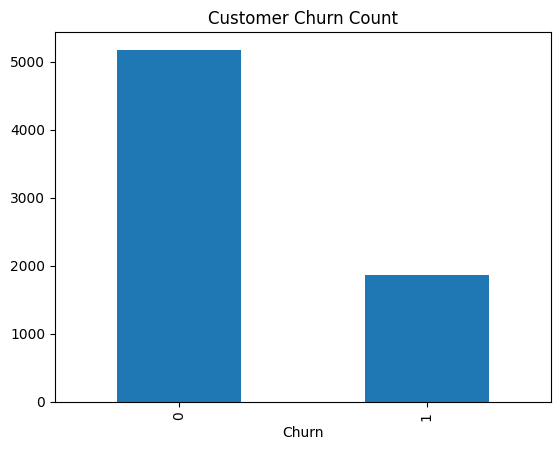

In [14]:
df1['Churn'].value_counts().plot(kind='bar')

plt.title('Customer Churn Count')
plt.show()

The dataset exhibits an imbalanced distribution, with a ratio of approximately 3:1 for Not-Churn to Churn customers. This imbalance introduces a bias in predictions, where the model may lean towards accurately predicting Not-Churn instances.


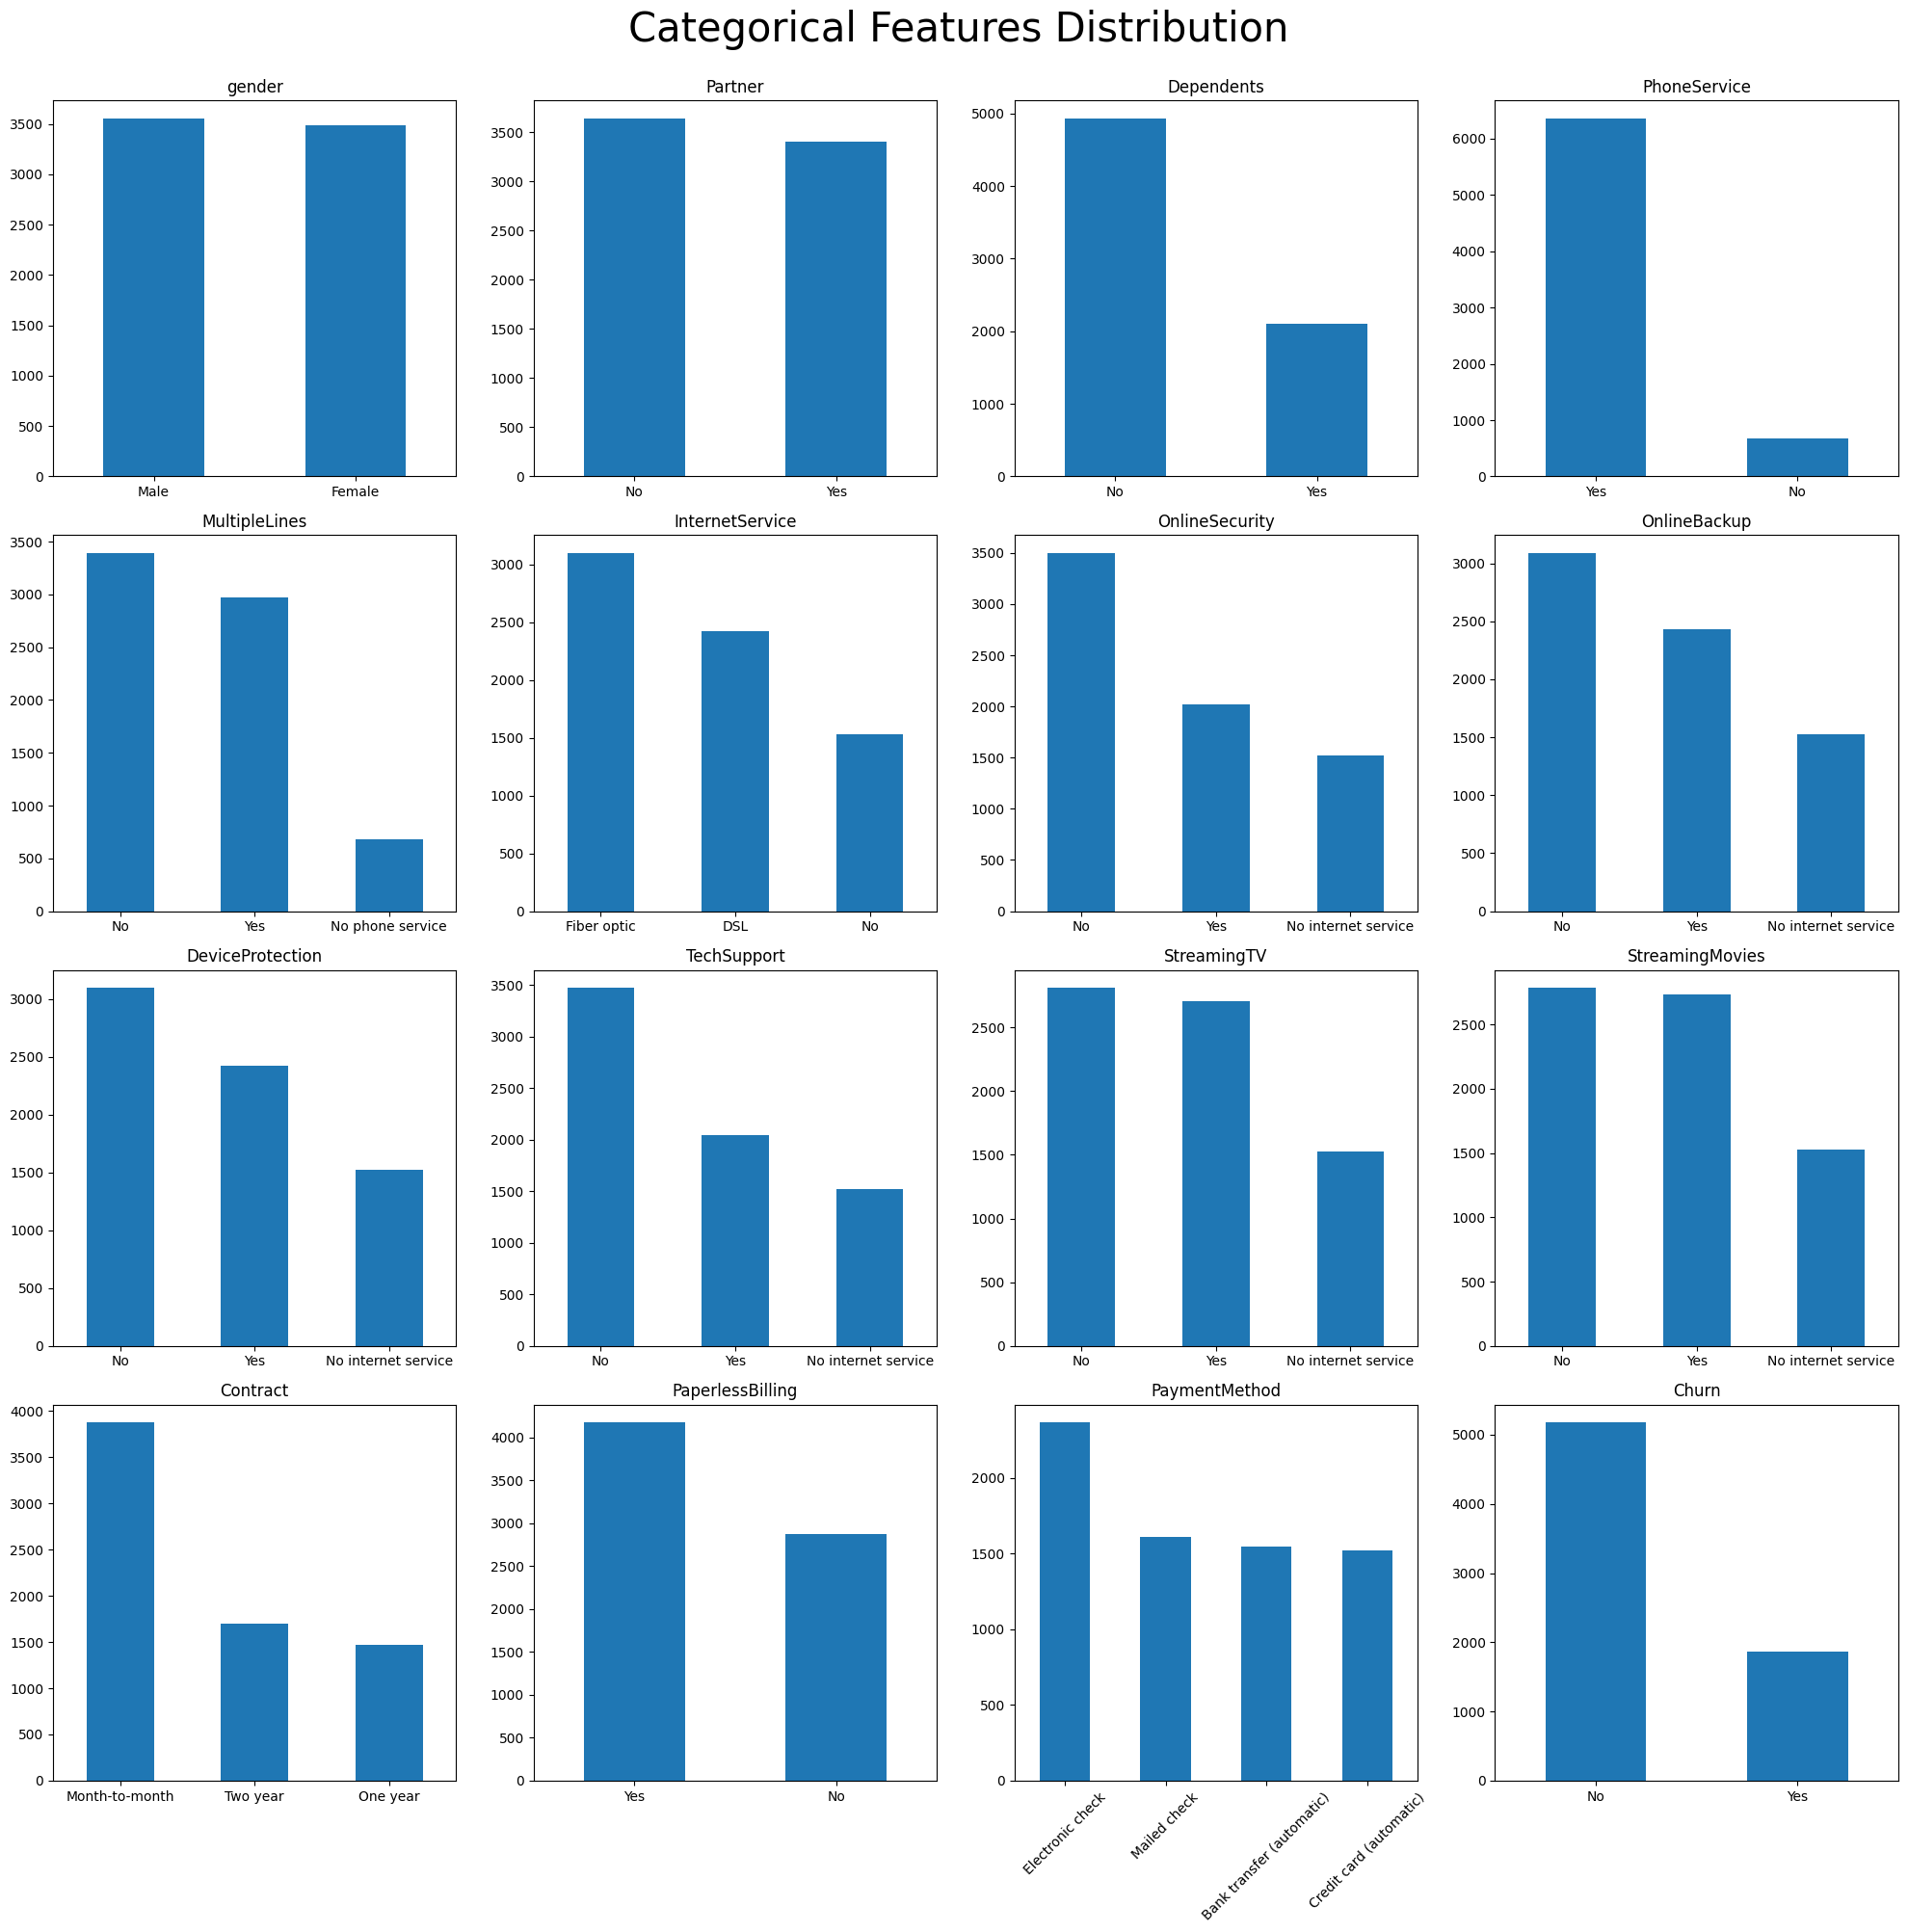

In [15]:
fig, axes= plt.subplots(4, 4, figsize= (20,20))
axes= axes.flatten()

for ax, col in zip(axes, text_cols):
    df[col].value_counts().plot(kind= 'bar', ax= ax)

    ax.set_title(col)

    if col=='PaymentMethod':
        ax.tick_params(axis= 'x', rotation=45)
    else:
        ax.tick_params(axis= 'x', rotation= 0)

    ax.set_xlabel('')
    ax.set_ylabel('')


plt.suptitle('Categorical Features Distribution', fontsize= 30, y= 1)

plt.tight_layout()
plt.show()

In [16]:
num_cols= ['tenure', 'MonthlyCharges', 'TotalCharges']

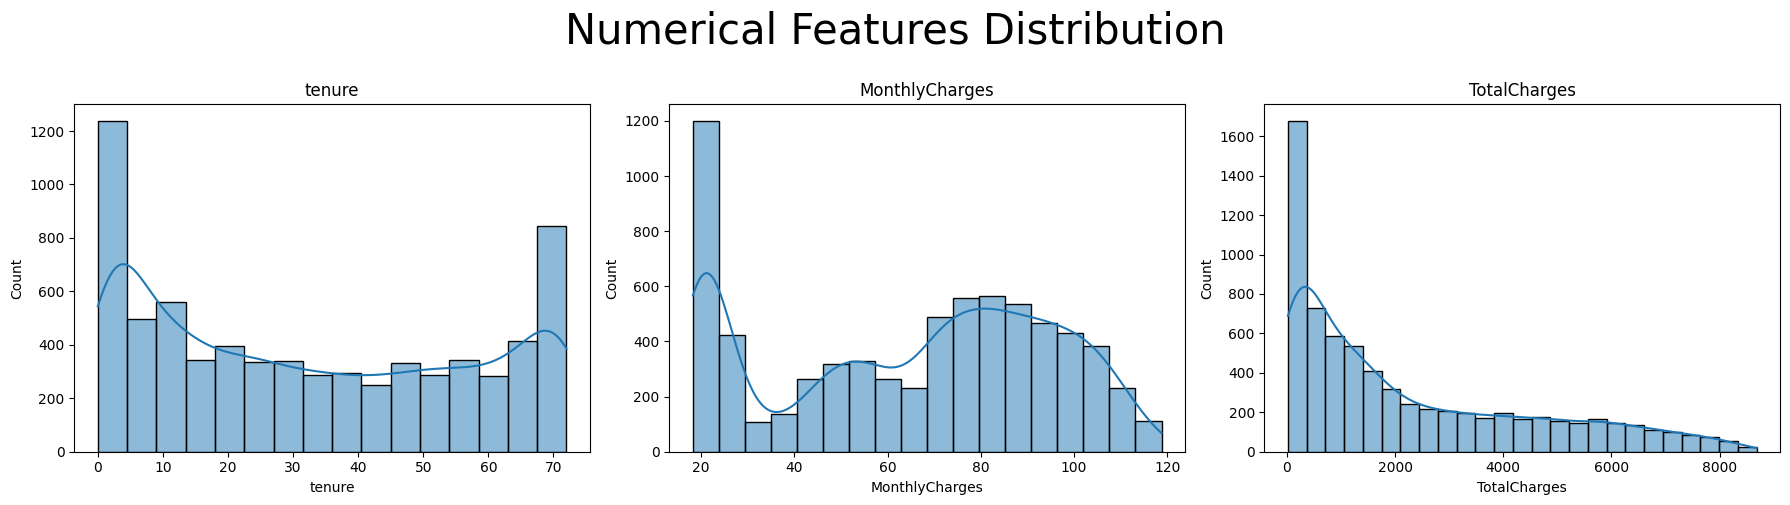

In [22]:
fig, axes= plt.subplots(1, 3, figsize= (18,5))

for ax, col in zip(axes, num_cols):
    sns.histplot(data= df, x= col, ax= ax, kde= True)
    ax.set_title(col)

plt.suptitle('Numerical Features Distribution', fontsize= 30, y= 1)

plt.tight_layout()
plt.show()

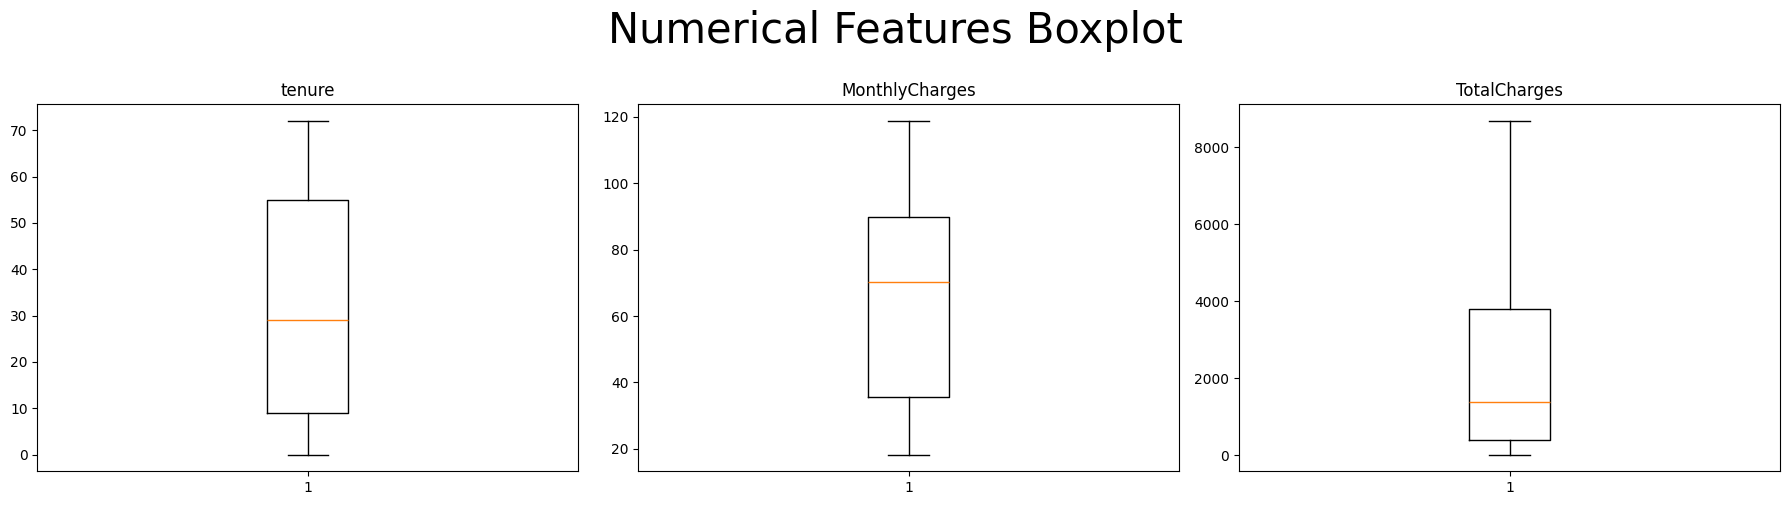

In [23]:
fig, axes= plt.subplots(1, 3, figsize= (18,5))

for ax, col in zip(axes, num_cols):
    ax.boxplot(df[col].dropna(), vert= True)
    ax.set_title(col)

plt.suptitle('Numerical Features Boxplot', fontsize= 30, y= 1)

plt.tight_layout()
plt.show()

# Exploratory Data Analysis:

In [19]:
# Customer-related information
customer_col= ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

# Customer-services related information
services_col= ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', "StreamingMovies"]

# Payment-related information
payment_col= ['Contract', "PaperlessBilling", 'PaymentMethod']

### Customer-related information:

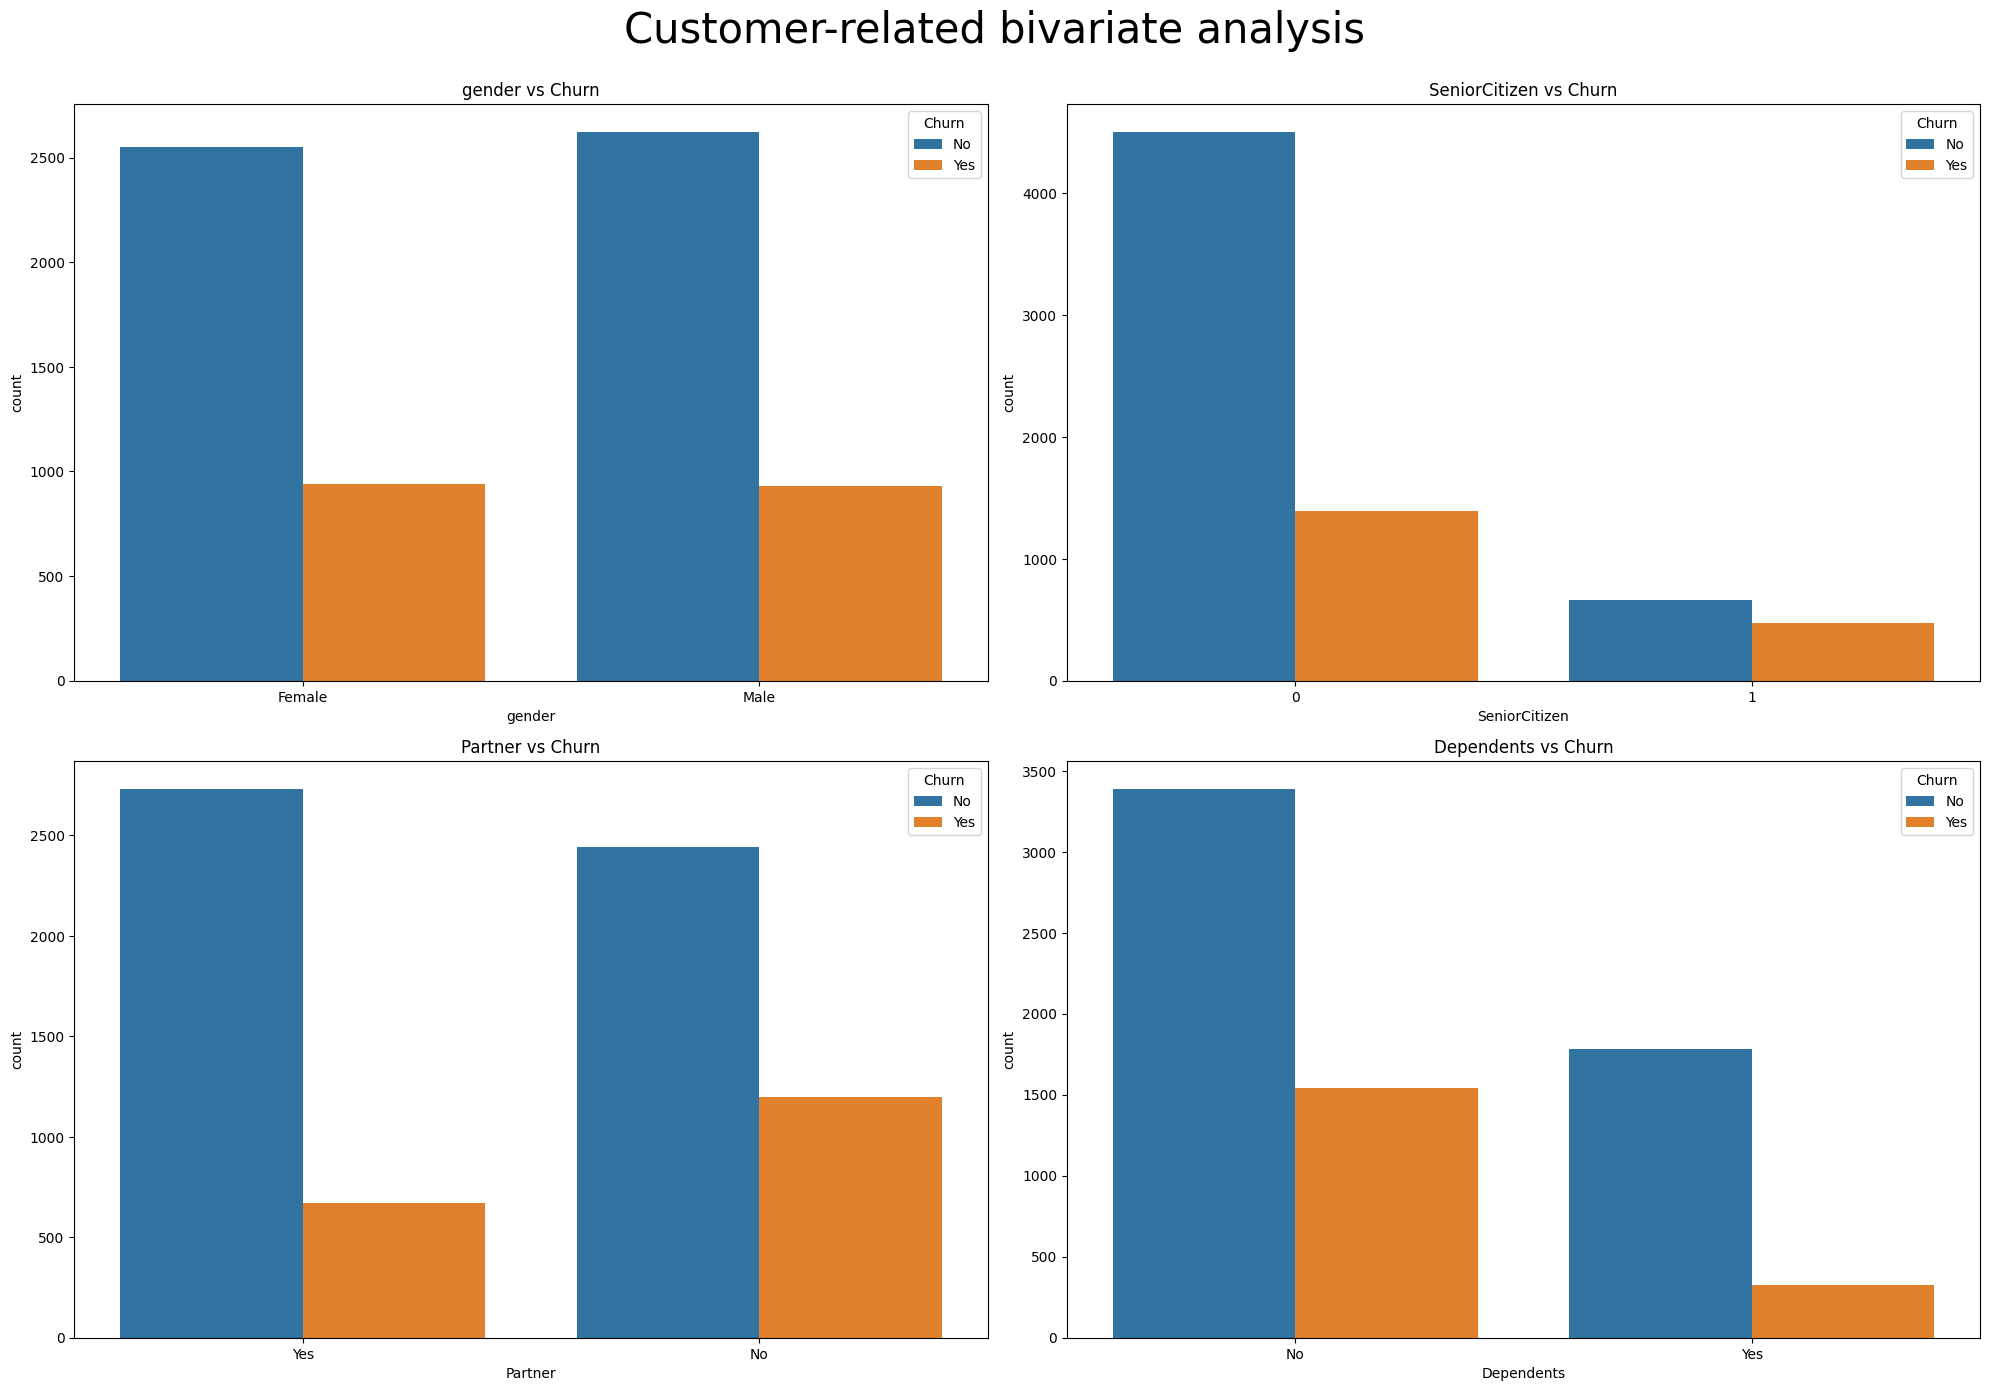

In [26]:
plt.figure(figsize= (20,20))

for i in range(len(customer_col)):
    plt.subplot(3, 2, i+1)
    sns.countplot(x= customer_col[i], data= df, hue= 'Churn')
    plt.title(customer_col[i] + ' vs Churn')

plt.suptitle('Customer-related bivariate analysis', fontsize= 30, y= 1)
plt.tight_layout()
plt.show()

- **Gender Churn Analysis**: Customer churn rates are comparable between male and female customers, indicating similarity in churn behavior across genders.

- **Senior Citizen Churn Analysis**: The number of Senior Citizen customers is relatively low. However, among Senior Citizens, most of them experienced churn.

- **Partner Status Impact**: Customers residing with a partner exhibit lower churn rates compared to those without a partner.

- **Dependents Influence**: Churn rates are higher for customers without dependents, suggesting a potential correlation between marital status and customer retention.

These observations provide insights into specific customer segments that may require targeted retention strategies. Understanding the nuanced behavior within these groups can aid in developing more tailored approaches for customer retention.

### Customer-Services related Information:

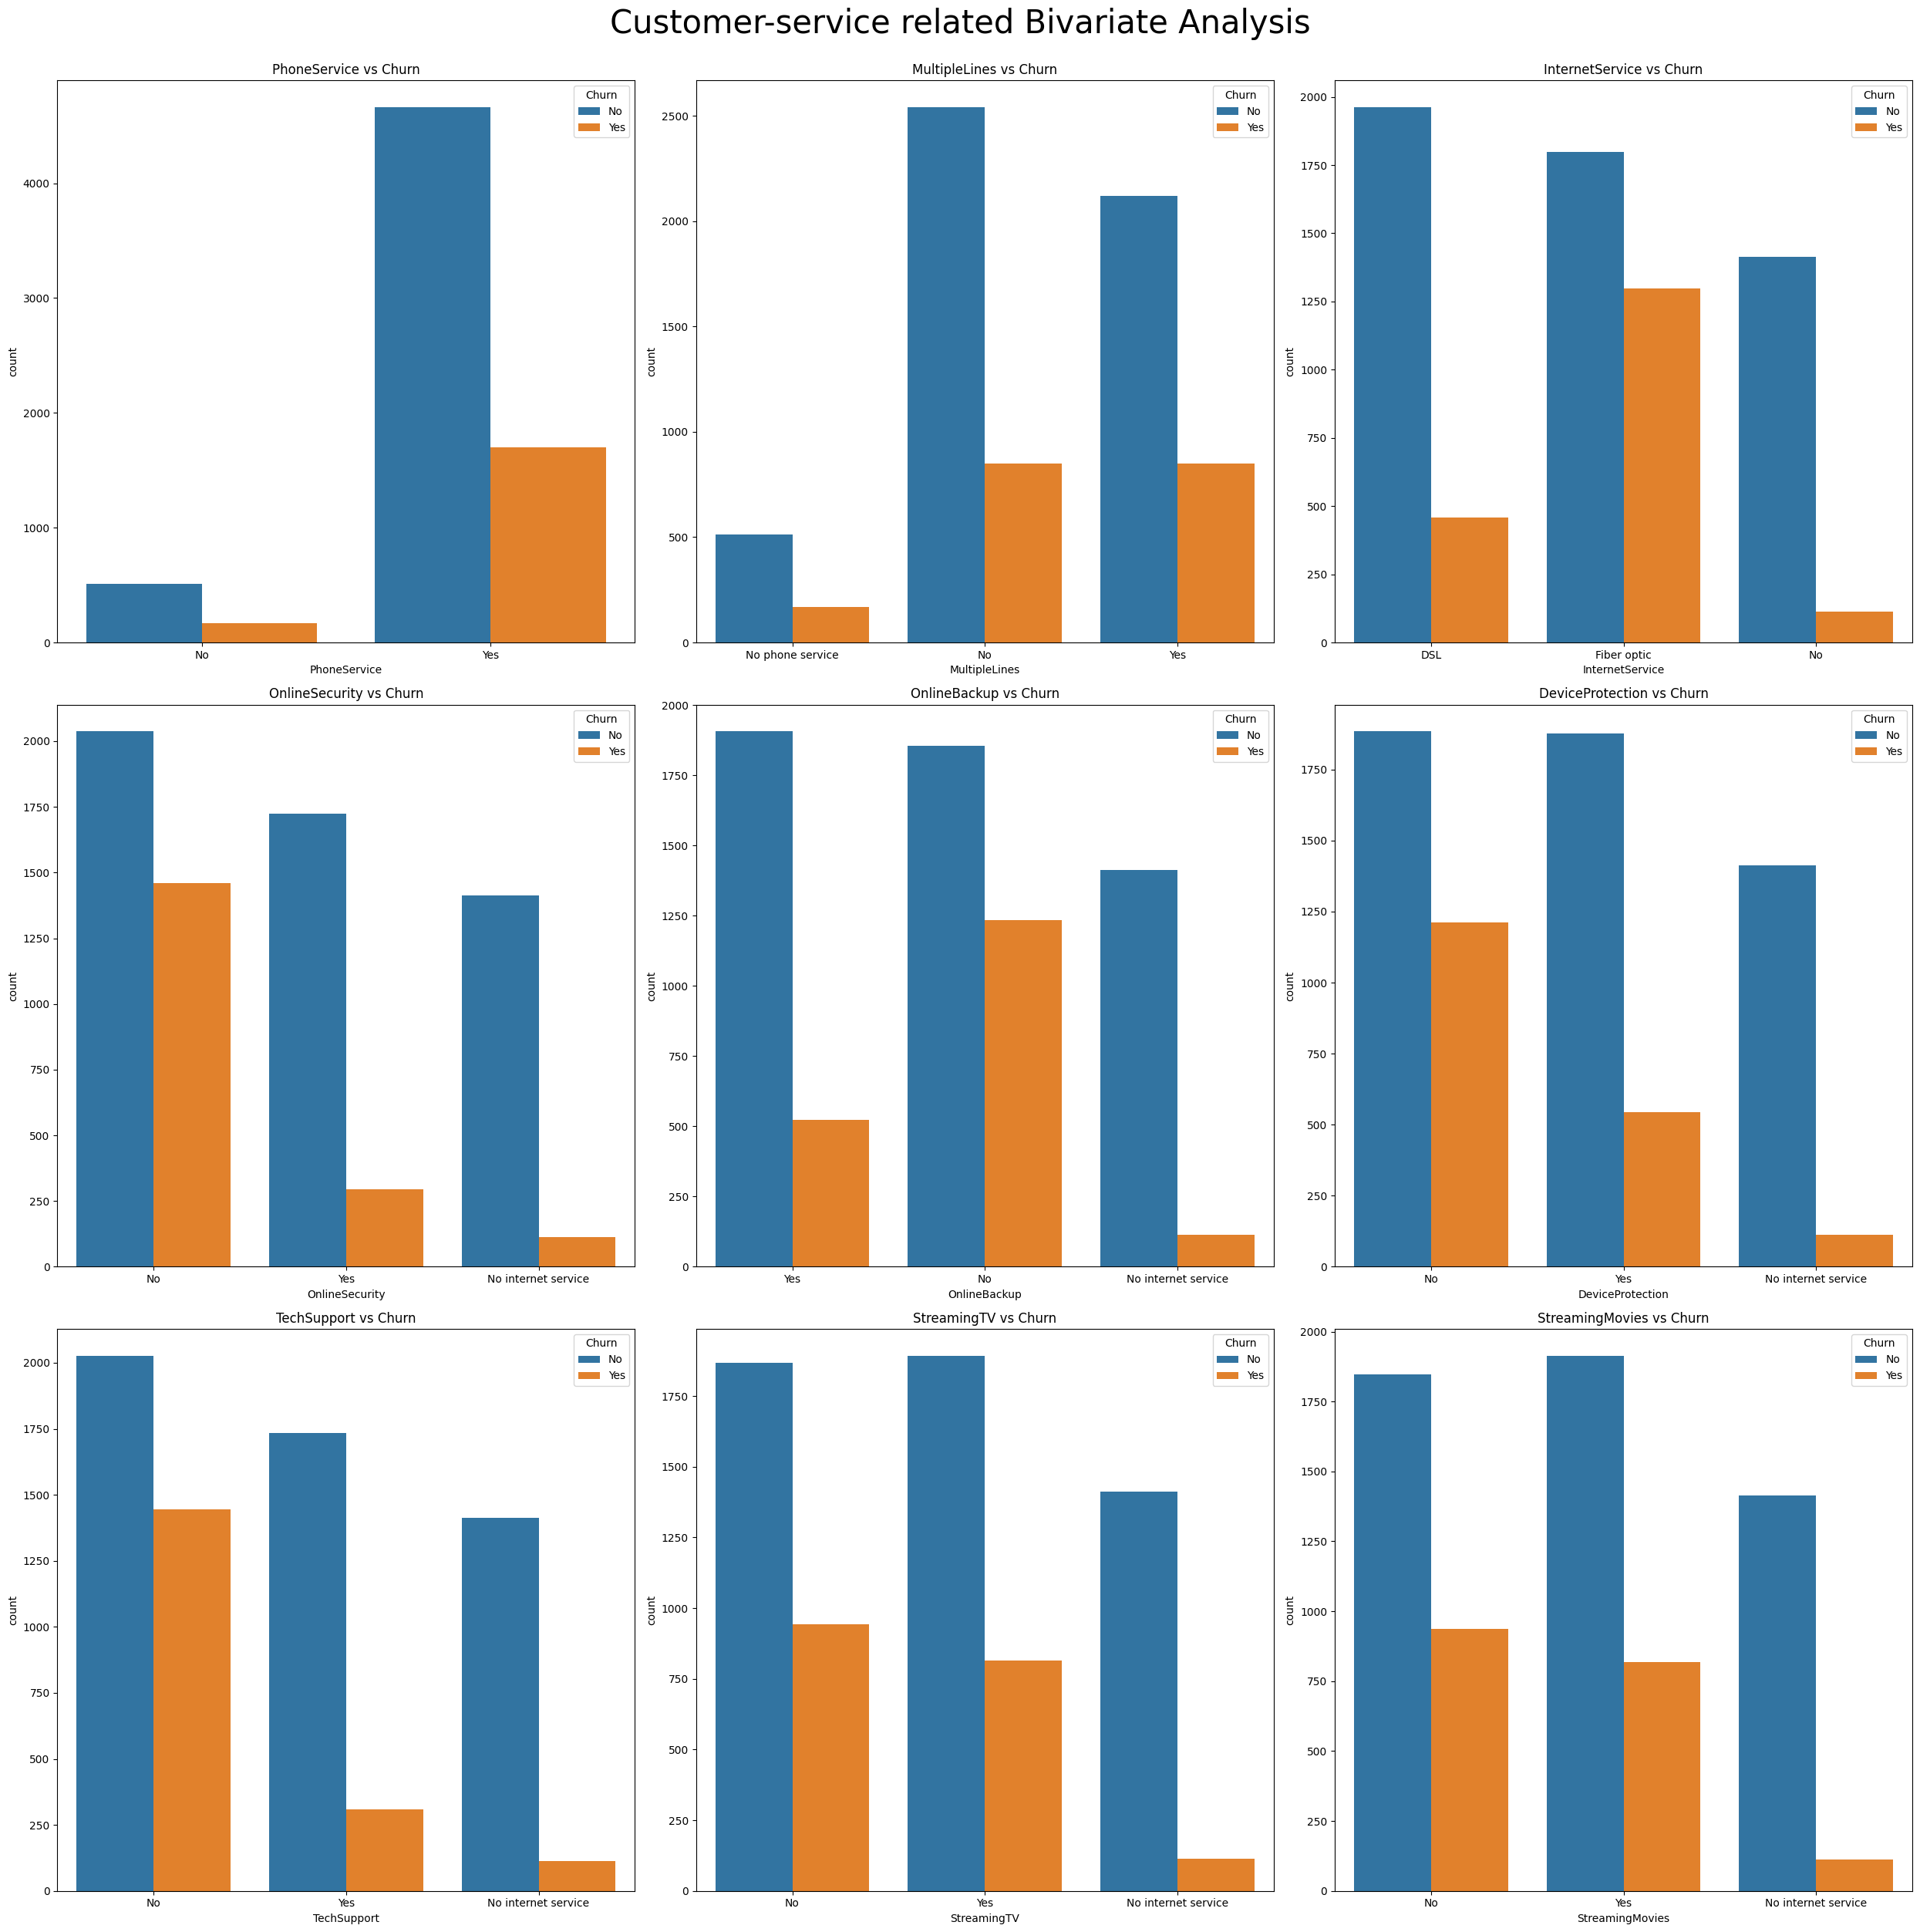

In [29]:
plt.figure(figsize= (25,25))

for i in range(len(services_col)):
    plt.subplot(3, 3, i+1)
    sns.countplot(x= services_col[i], data= df, hue= 'Churn')
    plt.title(services_col[i] + ' vs Churn')

plt.suptitle('Customer-service related Bivariate Analysis', fontsize= 30, y= 1)

plt.subplots_adjust(hspace= 0.3)
plt.tight_layout()
plt.show()

- **Phone Service Analysis**: Notably, a higher retention rate is observed among customers with no phone service compared to those who opted to discontinue the service.

- **Multiple Lines Analysis**: The churn rate appears consistent irrespective of whether customers have subscribed to multiple lines or not.

- **Internet Service Preference**: A considerable number of customers exhibit a preference against utilizing Fiber optic cables for InternetService. Conversely, the data suggests a greater inclination towards DSL among customers.

- **Streaming Services Analysis**: Both StreamingTV and StreamingMovies exhibit parallel churn patterns. Regardless of subscription status, a noteworthy number of customers have experienced churn. This implies that factors beyond streaming content alone contribute to customer disengagement.

- **Tech Support**: Customers with no tech support are more likely to churn than customers with tech support. 

These observations shed light on customer behavior concerning the services they avail, offering valuable insights for devising targeted strategies to enhance customer retention.

### Payment-related information:

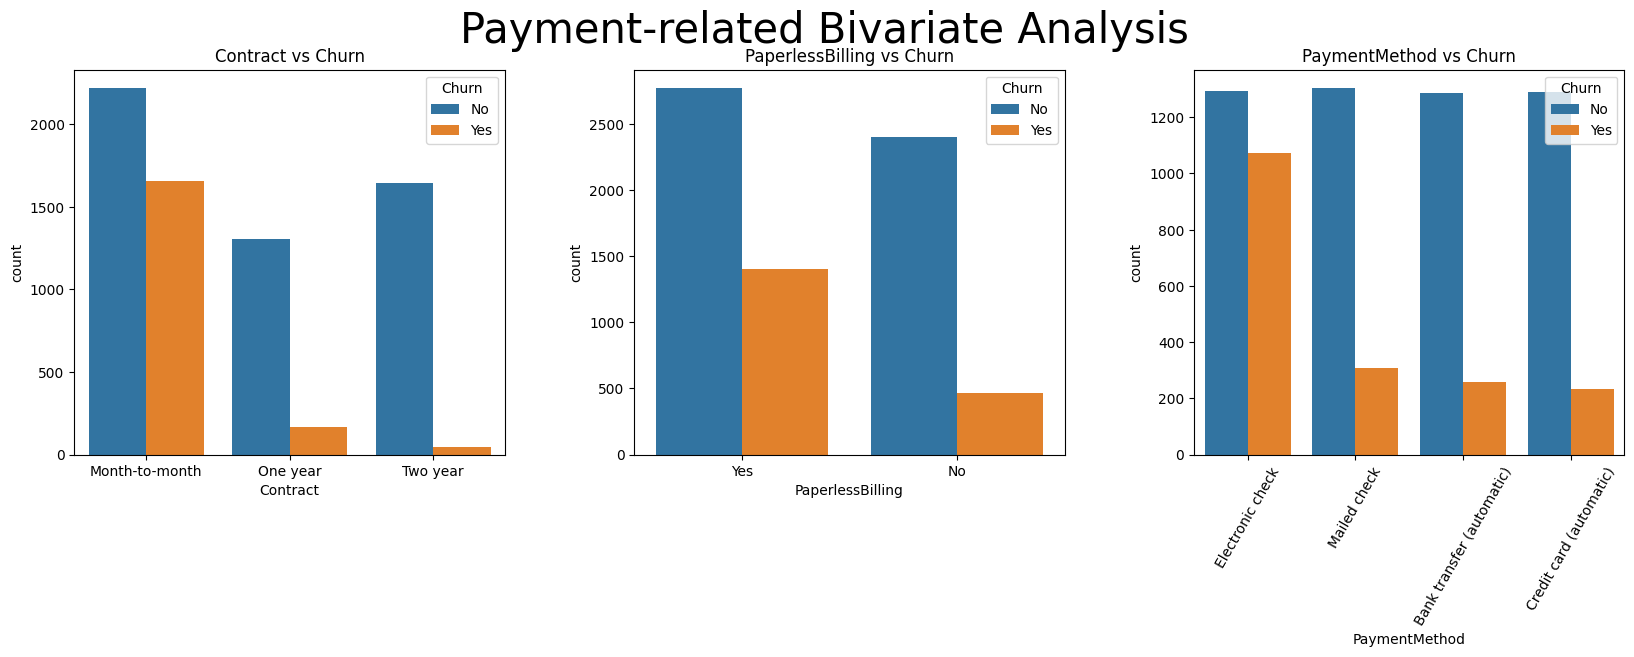

In [31]:
plt.figure(figsize= (20, 5))

for i in range(len(payment_col)):
    ax= plt.subplot(1, 3, i+1)
    sns.countplot(x= payment_col[i], data= df, hue= 'Churn')
    plt.title(payment_col[i] + ' vs Churn')
    if payment_col[i]=='PaymentMethod':
        ax.tick_params(axis= 'x', rotation= 60)

plt.suptitle('Payment-related Bivariate Analysis', fontsize= 30, y= 1)

plt.subplots_adjust(wspace= 0.3, hspace= 0.3)
plt.show()

- **Contract Analysis**: Customer churn is notably high for Month-to-Month contracts. This could be attributed to customers testing various services and opting for shorter-term commitments to explore available options or save costs.

- **Paperless Billing Impact**: A considerable number of customers experience churn in the presence of PaperlessBilling, suggesting potential issues related to payment or receipt processes.

- **Payment Method Insights**: Customers exhibit a strong aversion to the Electronic check payment method. Addressing issues with Electronic check or reconsidering its inclusion may be necessary for improved customer satisfaction.

These observations underscore the importance of understanding customer preferences in contractual terms, billing methods, and payment processes. Implementing measures to address specific pain points can contribute significantly to customer retention efforts.

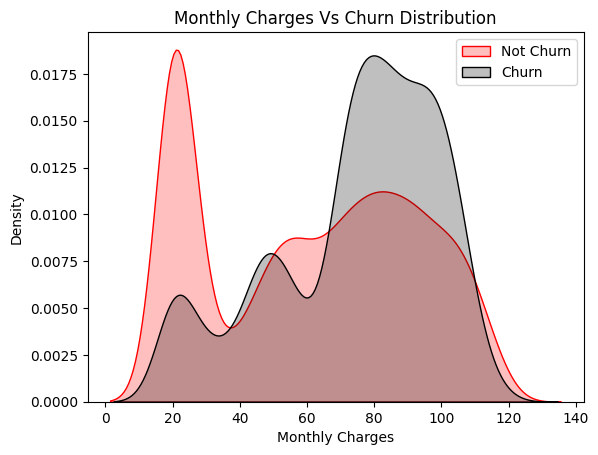

In [23]:
ax= sns.kdeplot(df1.MonthlyCharges[df1["Churn"]== 0], color= 'Red', fill= True)
ax= sns.kdeplot(df1.MonthlyCharges[df1["Churn"]== 1], color= 'Black', fill= True)

ax.legend(["Not Churn", "Churn"])
ax.set_xlabel("Monthly Charges")
ax.set_ylabel("Density")

ax.set_title("Monthly Charges Vs Churn Distribution")

plt.show()

Customers are more likely to churn due to the presence of high monthly charges.

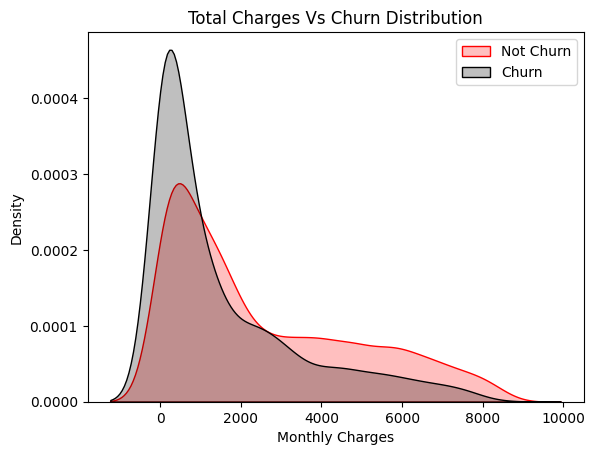

In [24]:
ax= sns.kdeplot(df1.TotalCharges[df1["Churn"]== 0], color= 'Red', fill= True)
ax= sns.kdeplot(df1.TotalCharges[df1["Churn"]== 1], color= 'Black', fill= True)

ax.legend(["Not Churn", "Churn"])
ax.set_xlabel("Monthly Charges")
ax.set_ylabel("Density")

ax.set_title("Total Charges Vs Churn Distribution")

plt.show()

The observation that high Total Charges are associated with a higher likelihood of customer churn suggests a potential issue with the pricing system. Addressing and optimizing the pricing structure is crucial to mitigate this factor contributing to customer churn. A thorough examination and potential adjustments in pricing strategies may help enhance customer satisfaction and retention.

### Overall Insights from Exploratory Data Analysis:

In customer churn analysis, certain categorical features reveal distinct hierarchies crucial for targeted retention strategies. `Male` customers are more likely to churn than `females`, while `Senior Citizens` exhibit lower churn rates. Not having a `partner` or `dependents` increases churn likelihood. Regarding services, having `phone service` and `multiple lines` correlates with lower churn, and `fiber optic internet users` are more prone to churn than `DSL users`. The absence of `online security`, `online backup`, etc., indicates higher churn.

Contract-wise, `month-to-month contracts` show higher churn than `one-year` and `two-year contracts`. `Paperless Billing` customers are more likely to churn. In payment methods, `electronic cheques` users have a higher churn risk, followed by `mailed cheques`, `bank transfers (automatic)` and `credit cards (automatic)`. Understanding these hierarchies is essential for devising effective retention strategies.